# Semi-expert evaluation analysys

This notebook reads `qualtrics_cleaned_responses.csv` and `qualtrics_codebook.csv`, then creates the colored diverging Likert plots for the semi-expert evaluation, and presents the open question responses in a table. 

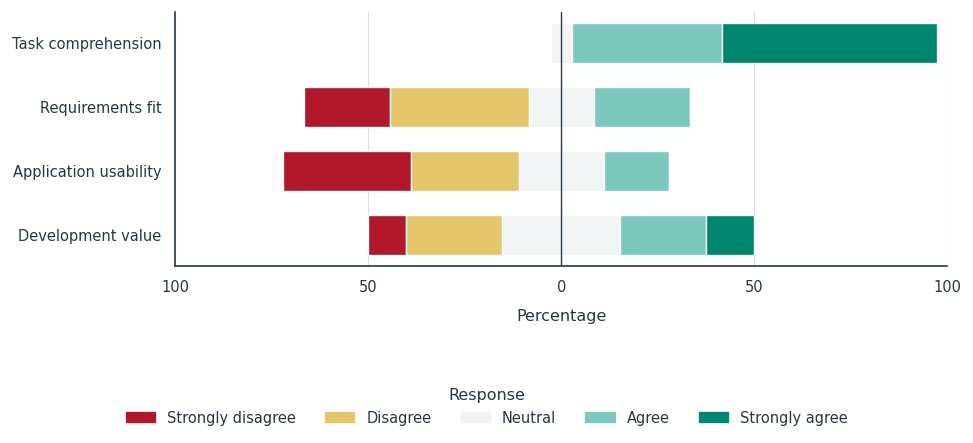

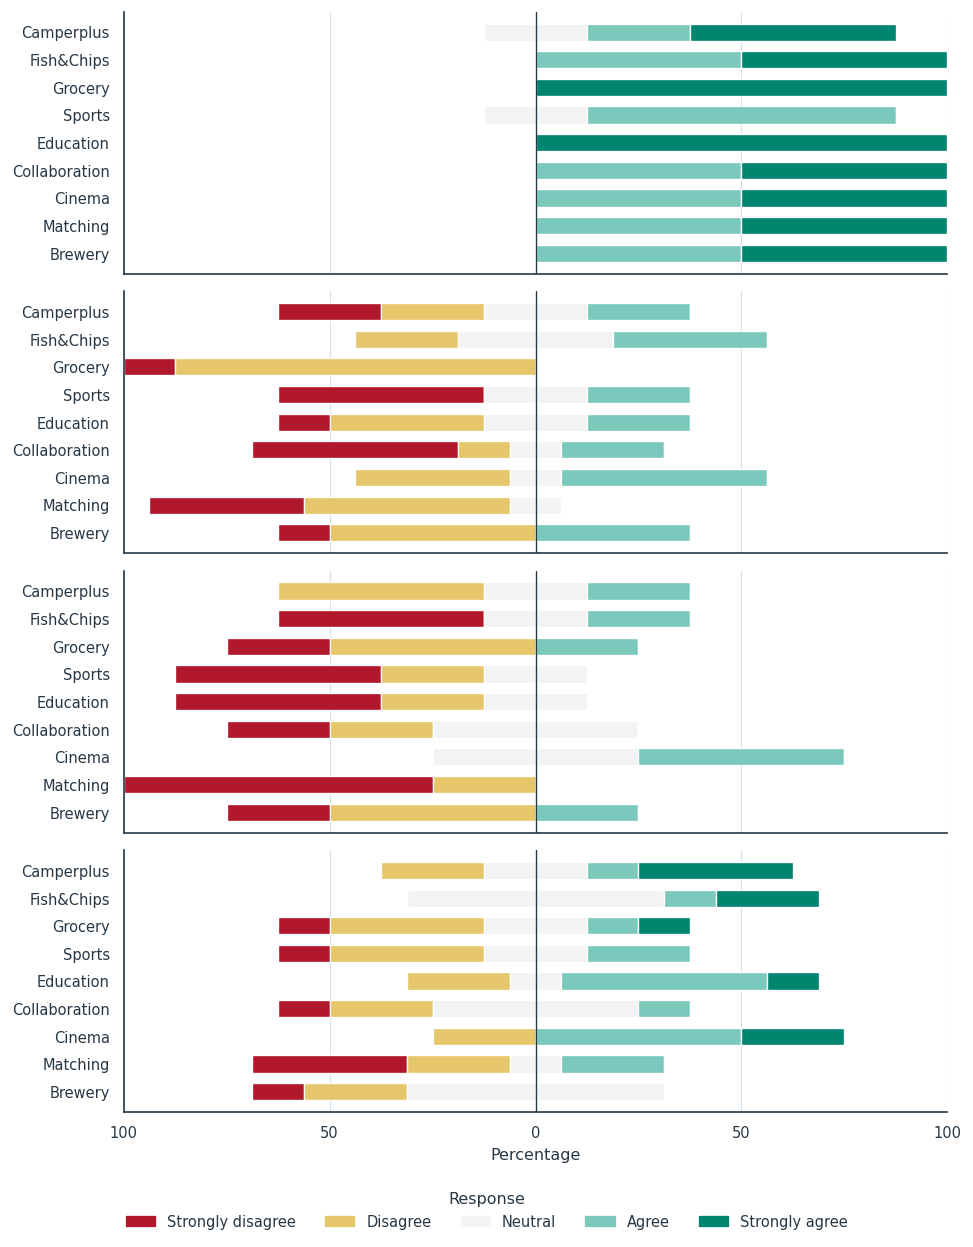

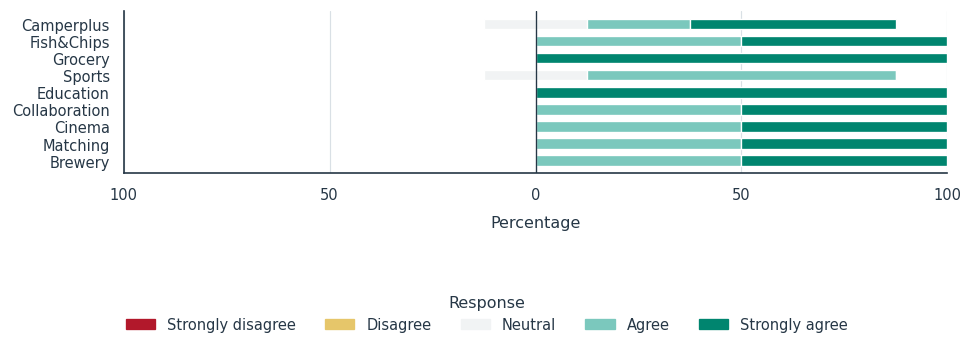

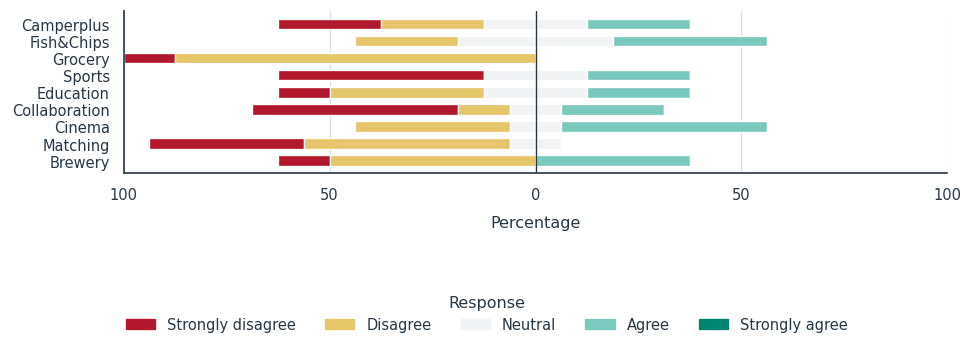

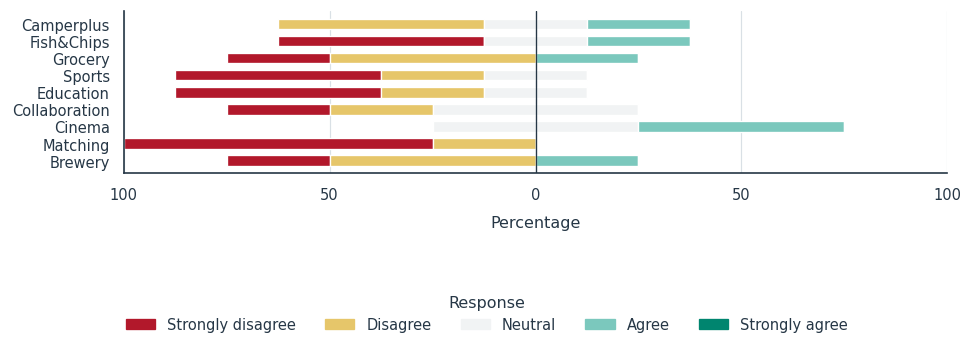

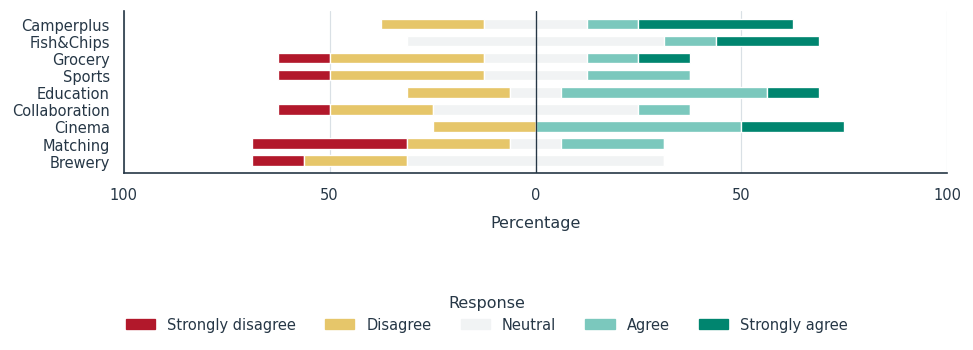

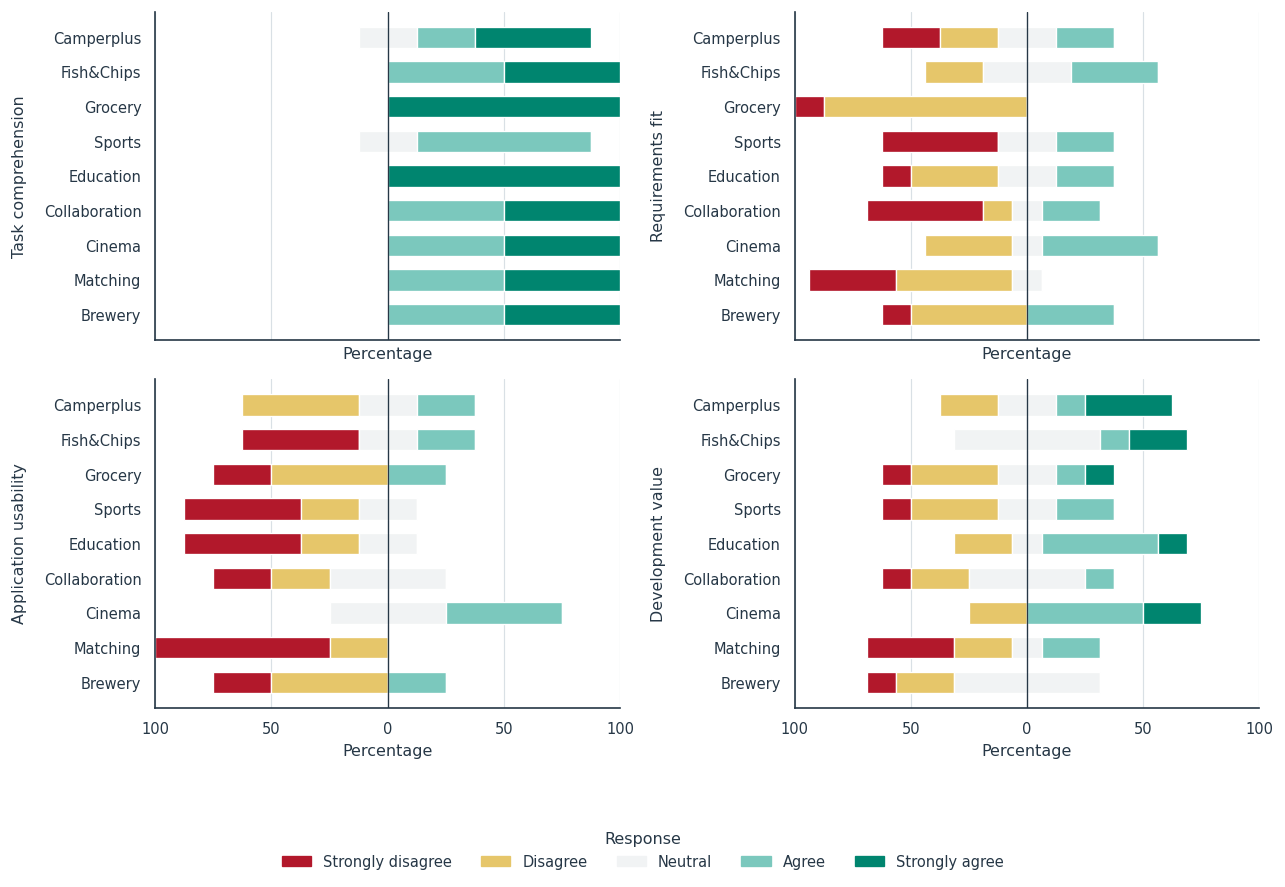

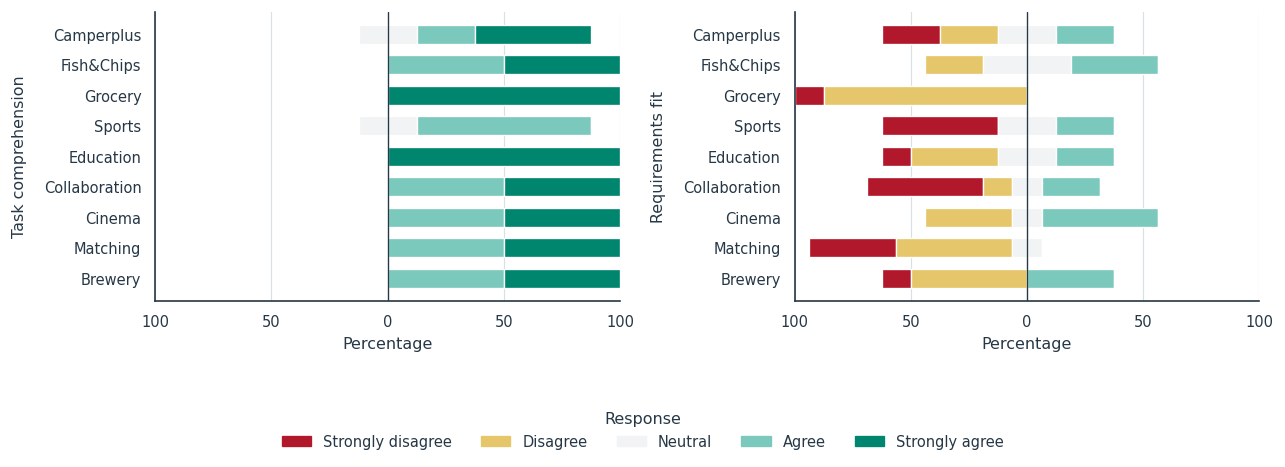

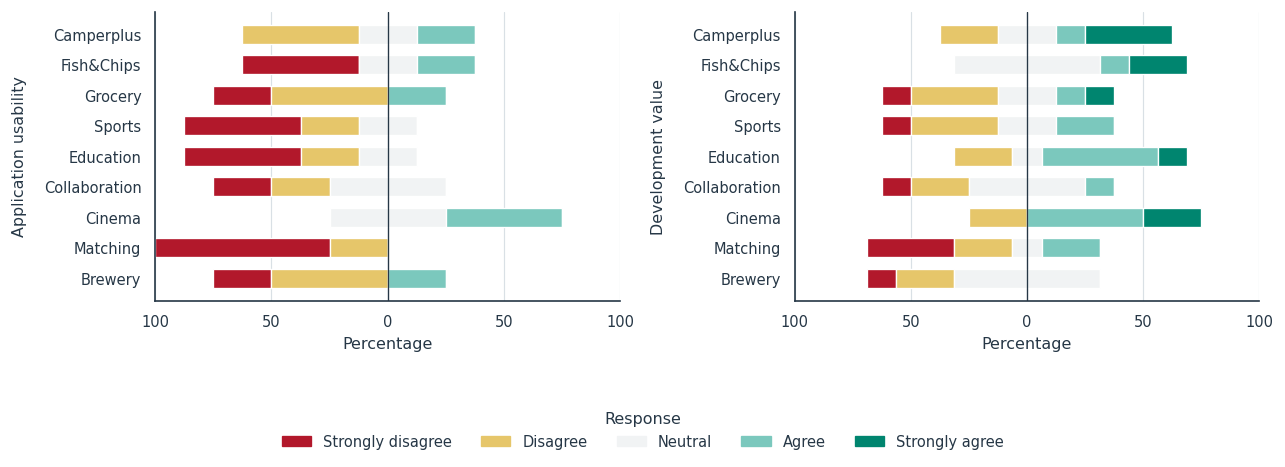

Loaded 9 finished responses from qualtrics_cleaned_responses.csv.
Using codebook columns from qualtrics_codebook.csv: 44 entries.
Long Likert rows plotted: 216


In [4]:
from pathlib import Path
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

def find_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / 'pipeline').exists() and (candidate / 'evaluation').exists():
            return candidate
    raise RuntimeError('Could not locate replication package root.')

REPO_ROOT = find_repo_root(Path.cwd().resolve())
ANALYSIS_DIR = REPO_ROOT / 'evaluation/qualitative_analysis/analysis'
RESPONSES_CSV = ANALYSIS_DIR / 'qualtrics_cleaned_responses.csv'
CODEBOOK_CSV = ANALYSIS_DIR / 'qualtrics_codebook.csv'
FIGURE_DIR = ANALYSIS_DIR / 'figures'
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

responses = pd.read_csv(RESPONSES_CSV, keep_default_na=False)
codebook = pd.read_csv(CODEBOOK_CSV, keep_default_na=False)
documented_columns = codebook['Cleaned column'].tolist()

finished = responses.loc[
    pd.to_numeric(responses['Finished'], errors='coerce').eq(1)
    & pd.to_numeric(responses['Progress'], errors='coerce').eq(100)
].copy()

APP_ORDER = [
    'camperplus', 'fish_chips', 'grocery', 'sports', 'education',
    'collaboration', 'cinema', 'matching', 'brewery',
]
APP_LABELS = {
    'camperplus': 'Camperplus',
    'fish_chips': 'Fish&Chips',
    'grocery': 'Grocery',
    'sports': 'Sports',
    'education': 'Education',
    'collaboration': 'Collaboration',
    'cinema': 'Cinema',
    'matching': 'Matching',
    'brewery': 'Brewery',
}
CONSTRUCT_ITEMS = {
    'Task comprehension': ['Understand user stories', 'Understand evaluation task'],
    'Requirements fit': [
        'Accurately reflects user stories',
        'Covers important details',
        'Data model fit',
        'Workflow/process present',
    ],
    'Application usability': ['Navigation logical', 'Access/functionality fits roles'],
    'Development value': [
        'Model understandable for development',
        'Generated structure helpful',
        'Useful as starting point',
        'Would reduce manual development effort',
    ],
}
CONSTRUCT_ORDER = list(CONSTRUCT_ITEMS)

LIKERT_RESPONSES = ['Strongly disagree', 'Disagree', 'Neutral', 'Agree', 'Strongly agree']
SCORE_TO_RESPONSE = {
    1: 'Strongly disagree',
    2: 'Disagree',
    3: 'Neutral',
    4: 'Agree',
    5: 'Strongly agree',
}
LIKERT_COLORS = {
    'Strongly disagree': '#B2182B',
    'Disagree': '#E6C66A',
    'Neutral': '#F1F3F4',
    'Agree': '#7BC8BD',
    'Strongly agree': '#00856F',
}
DARK = '#263746'
GRID = '#D9E0E5'

sns.set_theme(
    context='paper',
    style='whitegrid',
    font='DejaVu Sans',
    rc={
        'figure.dpi': 120,
        'savefig.dpi': 300,
        'pdf.fonttype': 42,
        'ps.fonttype': 42,
        'svg.fonttype': 'none',
        'axes.edgecolor': DARK,
        'axes.labelcolor': DARK,
        'axes.titlecolor': DARK,
        'axes.titleweight': 'semibold',
        'grid.color': GRID,
        'grid.linewidth': 0.7,
        'xtick.color': DARK,
        'ytick.color': DARK,
        'text.color': DARK,
    },
)


def normalize_app_id(value):
    return str(value).strip().lower()


def item_name(column):
    return re.sub(r'^App [12]:\s*', '', column)


def construct_for_column(column):
    item = item_name(column)
    for construct, items in CONSTRUCT_ITEMS.items():
        if item in items:
            return construct
    return None


def export_figure(fig, stem):
    fig.savefig(FIGURE_DIR / f'{stem}.pdf', format='pdf', bbox_inches='tight')
    fig.savefig(FIGURE_DIR / f'{stem}.png', format='png', dpi=300, bbox_inches='tight')


def likert_percentages(data, group_col, group_order):
    counts = (
        data.groupby([group_col, 'response'])
        .size()
        .unstack(fill_value=0)
        .reindex(index=group_order, columns=LIKERT_RESPONSES, fill_value=0)
    )
    totals = counts.sum(axis=1).replace(0, np.nan)
    return counts.div(totals, axis=0).mul(100).fillna(0)


def plot_diverging_likert(ax, percentages, labels, *, title=None):
    y = np.arange(len(percentages))
    strong_disagree = percentages['Strongly disagree'].to_numpy()
    disagree = percentages['Disagree'].to_numpy()
    neutral = percentages['Neutral'].to_numpy()
    agree = percentages['Agree'].to_numpy()
    strong_agree = percentages['Strongly agree'].to_numpy()

    left = -(strong_disagree + disagree + neutral / 2)
    ax.barh(y, strong_disagree, left=left, color=LIKERT_COLORS['Strongly disagree'], height=0.62)
    left = left + strong_disagree
    ax.barh(y, disagree, left=left, color=LIKERT_COLORS['Disagree'], height=0.62)
    ax.barh(y, neutral, left=-(neutral / 2), color=LIKERT_COLORS['Neutral'], height=0.62)
    right = neutral / 2
    ax.barh(y, agree, left=right, color=LIKERT_COLORS['Agree'], height=0.62)
    right = right + agree
    ax.barh(y, strong_agree, left=right, color=LIKERT_COLORS['Strongly agree'], height=0.62)

    ax.axvline(0, color=DARK, linewidth=0.8)
    ax.set_xlim(-100, 100)
    ax.set_xticks([-100, -50, 0, 50, 100])
    ax.set_xticklabels(['100', '50', '0', '50', '100'])
    ax.set_yticks(y)
    ax.set_yticklabels(labels)
    ax.invert_yaxis()
    ax.set_xlabel('Percentage')
    if title:
        ax.set_title(title, fontsize=9.5)
    ax.grid(axis='y', visible=False)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)


records = []
for app_slot in (1, 2):
    app_id_col = f'App {app_slot} ID'
    question_columns = [
        col for col in documented_columns
        if col.startswith(f'App {app_slot}:') and 'Attention check' not in col
    ]
    for _, row in finished.iterrows():
        app_id = normalize_app_id(row[app_id_col])
        if app_id in {'', 'n/a', 'na', 'n.a.', 'not applicable'}:
            continue
        for column in question_columns:
            construct = construct_for_column(column)
            if construct is None:
                continue
            score = pd.to_numeric(row[column], errors='coerce')
            if pd.isna(score):
                continue
            records.append(
                {
                    'participant_id': row['Participant ID'],
                    'app_id': app_id,
                    'app_label': APP_LABELS.get(app_id, app_id),
                    'construct': construct,
                    'item': item_name(column),
                    'score': int(score),
                    'response': SCORE_TO_RESPONSE[int(score)],
                }
            )

likert_long = pd.DataFrame.from_records(records)
observed_app_order = [app_id for app_id in APP_ORDER if app_id in set(likert_long['app_id'])]
observed_app_labels = [APP_LABELS.get(app_id, app_id) for app_id in observed_app_order]

construct_percentages = likert_percentages(likert_long, 'construct', CONSTRUCT_ORDER)
fig, ax = plt.subplots(figsize=(8.2, 3.7))
plot_diverging_likert(ax, construct_percentages, CONSTRUCT_ORDER)
handles = [plt.Rectangle((0, 0), 1, 1, color=LIKERT_COLORS[response]) for response in LIKERT_RESPONSES]
ax.set_xlabel('Percentage', labelpad=8)
fig.legend(
    handles,
    LIKERT_RESPONSES,
    title='Response',
    frameon=False,
    ncol=5,
    loc='lower center',
    bbox_to_anchor=(0.5, 0.0),
)
fig.tight_layout(rect=(0, 0.22, 1, 1))
export_figure(fig, 'semi_expert_likert_distribution_by_construct')
plt.show()

fig, axes = plt.subplots(len(CONSTRUCT_ORDER), 1, figsize=(8.2, 10.4), sharex=True)
for ax, construct in zip(axes, CONSTRUCT_ORDER):
    subset = likert_long.loc[likert_long['construct'].eq(construct)].copy()
    percentages = likert_percentages(subset, 'app_label', observed_app_labels)
    plot_diverging_likert(ax, percentages, observed_app_labels)
    ax.set_xlabel('' if ax is not axes[-1] else 'Percentage')

fig.legend(
    handles,
    LIKERT_RESPONSES,
    title='Response',
    frameon=False,
    ncol=5,
    loc='lower center',
    bbox_to_anchor=(0.5, -0.01),
)
fig.tight_layout(rect=(0, 0.04, 1, 0.99))
export_figure(fig, 'semi_expert_likert_distribution_by_construct_app')
plt.show()


def slugify_construct(value: str) -> str:
    return (
        value.lower()
        .replace('&', 'and')
        .replace('/', '_')
        .replace(' ', '_')
        .replace('-', '_')
    )


for construct in CONSTRUCT_ORDER:
    subset = likert_long.loc[likert_long['construct'].eq(construct)].copy()
    percentages = likert_percentages(subset, 'app_label', observed_app_labels)

    fig, ax = plt.subplots(figsize=(8.2, 2.9))
    plot_diverging_likert(ax, percentages, observed_app_labels)
    ax.set_xlabel('Percentage', labelpad=8)
    fig.legend(
        handles,
        LIKERT_RESPONSES,
        title='Response',
        frameon=False,
        ncol=5,
        loc='lower center',
        bbox_to_anchor=(0.5, -0.01),
    )
    fig.tight_layout(rect=(0, 0.27, 1, 1))
    export_figure(fig, f'semi_expert_likert_distribution_by_construct_app_{slugify_construct(construct)}')
    plt.show()

fig, axes = plt.subplots(2, 2, figsize=(10.8, 7.4), sharex=True)
for ax, construct in zip(axes.ravel(), CONSTRUCT_ORDER):
    subset = likert_long.loc[likert_long['construct'].eq(construct)].copy()
    percentages = likert_percentages(subset, 'app_label', observed_app_labels)
    plot_diverging_likert(ax, percentages, observed_app_labels)
    ax.set_ylabel(construct, fontsize=9.5, labelpad=10)
    ax.set_xlabel('Percentage')

fig.legend(
    handles,
    LIKERT_RESPONSES,
    title='Response',
    frameon=False,
    ncol=5,
    loc='lower center',
    bbox_to_anchor=(0.5, 0.0),
)
fig.tight_layout(rect=(0, 0.12, 1, 1))
export_figure(fig, 'semi_expert_likert_distribution_by_construct_app_2x2')
plt.show()

construct_pairs = [
    CONSTRUCT_ORDER[:2],
    CONSTRUCT_ORDER[2:],
]
for pair_index, construct_pair in enumerate(construct_pairs, start=1):
    fig, axes = plt.subplots(1, 2, figsize=(10.8, 3.9), sharex=True)
    for ax, construct in zip(axes, construct_pair):
        subset = likert_long.loc[likert_long['construct'].eq(construct)].copy()
        percentages = likert_percentages(subset, 'app_label', observed_app_labels)
        plot_diverging_likert(ax, percentages, observed_app_labels)
        ax.set_ylabel(construct, fontsize=9.5, labelpad=10)
        ax.set_xlabel('Percentage')

    fig.legend(
        handles,
        LIKERT_RESPONSES,
        title='Response',
        frameon=False,
        ncol=5,
        loc='lower center',
        bbox_to_anchor=(0.5, 0.0),
    )
    fig.tight_layout(rect=(0, 0.2, 1, 1))
    export_figure(fig, f'semi_expert_likert_distribution_by_construct_app_1x2_{pair_index}')
    plt.show()

print(f'Loaded {len(finished)} finished responses from {RESPONSES_CSV.name}.')
print(f'Using codebook columns from {CODEBOOK_CSV.name}: {len(codebook)} entries.')
print(f'Long Likert rows plotted: {len(likert_long)}')


In [5]:
OPEN_QUESTION_COLUMNS = [
    "Strongest aspects",
    "Missing/incorrect elements",
    "Continue development?",
    "Needed improvements",
    "Additional comments",
]

open_questions_source = finished[
    ["Participant ID", "App 1 ID", "App 2 ID", *OPEN_QUESTION_COLUMNS]
].copy()

for app_column in ["App 1 ID", "App 2 ID"]:
    open_questions_source[app_column] = (
        open_questions_source[app_column]
        .map(normalize_app_id)
        .map(lambda app_id: APP_LABELS.get(app_id, app_id))
    )

open_questions_table = (
    open_questions_source
    .rename(columns={
        "Participant ID": "Participant",
        "App 1 ID": "App 1",
        "App 2 ID": "App 2",
    })
    .replace("", pd.NA)
    .melt(
        id_vars=["Participant", "App 1", "App 2"],
        value_vars=OPEN_QUESTION_COLUMNS,
        var_name="Question",
        value_name="Response",
    )
    .dropna(subset=["Response"])
    .sort_values(["Participant", "Question"], kind="stable")
    .reset_index(drop=True)
)

styled_open_questions_table = (
    open_questions_table.style
    .hide(axis="index")
    .set_properties(**{
        "text-align": "left",
        "vertical-align": "top",
        "white-space": "pre-wrap",
        "line-height": "1.35",
    })
    .set_table_styles([
        {"selector": "th", "props": [("text-align", "left"), ("font-weight", "600")]},
        {"selector": "td", "props": [("padding", "0.45rem 0.6rem")]},
        {"selector": "th", "props": [("padding", "0.45rem 0.6rem")]},
        {"selector": "tbody tr:nth-child(even)", "props": [("background-color", "#f7f7f7")]},
    ])
)

display(styled_open_questions_table)


Participant,App 1,App 2,Question,Response
p1,Matching,Sports,Additional comments,The sports one is much more better than the matching one. It seems to me that there are always two roles appear in on user story in the matching one which could make LLM confused.
p1,Matching,Sports,Continue development?,"For the sports one I would not for the matching one, which i'd rather start from zero."
p1,Matching,Sports,Missing/incorrect elements,most relationships
p1,Matching,Sports,Needed improvements,"domain model dirst. I need to adjust the entities ,relationships and attributes. then the pages layout and logic flows"
p1,Matching,Sports,Strongest aspects,entities and some relationships
p12,Grocery,Brewery,Additional comments,"lovely idea, maybe try AI agents."
p12,Grocery,Brewery,Continue development?,"No, because it starts with the domain model. When the domain model is not right, the mendix app is useless."
p12,Grocery,Brewery,Missing/incorrect elements,"Correct domain model, missing or wrong associations no validations in the domain model. No description in the domain model."
p12,Grocery,Brewery,Needed improvements,Improve domain model and build from that point to a AI generated app.
p12,Grocery,Brewery,Strongest aspects,The created pages are the most postive aspect of the generated applications.
